BAI 1

BAI 1 - A.TIEN XU LY

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


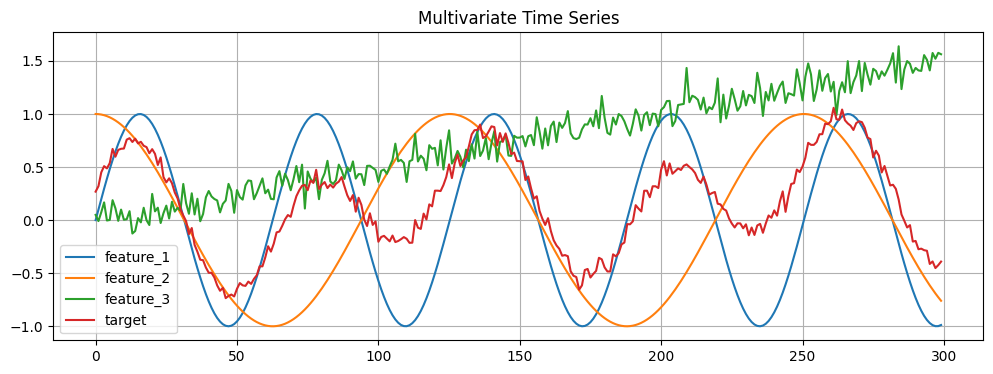

Train: 210
Validation: 45
Test: 45
X_train: (190, 20, 3)
y_train: (190, 1)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)

# ======================
# Tạo dữ liệu
# ======================

time_steps = 300

t = np.linspace(0, 30, time_steps)

feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)

target = (
    0.5 * feature_1
    + 0.3 * feature_2
    + 0.2 * feature_3
    + 0.05 * np.random.randn(time_steps)
)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target
})

print(df.head())

# ======================
# Vẽ dữ liệu
# ======================

plt.figure(figsize=(12,4))

for col in df.columns:
    plt.plot(df[col], label=col)

plt.legend()
plt.grid()
plt.title("Multivariate Time Series")
plt.show()

# ======================
# Chia dữ liệu
# 70% train
# 15% val
# 15% test
# ======================

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ======================
# Chuẩn hóa
# Fit scaler chỉ trên train
# ======================

feature_cols = [
    'feature_1',
    'feature_2',
    'feature_3'
]

target_col = ['target']

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(train_df[feature_cols])
y_scaler.fit(train_df[target_col])

X_train_scaled = x_scaler.transform(train_df[feature_cols])
X_val_scaled = x_scaler.transform(val_df[feature_cols])
X_test_scaled = x_scaler.transform(test_df[feature_cols])

y_train_scaled = y_scaler.transform(train_df[target_col])
y_val_scaled = y_scaler.transform(val_df[target_col])
y_test_scaled = y_scaler.transform(test_df[target_col])

# ======================
# Sliding Window
# ======================

seq_length = 20

def create_sequences(X, y, seq_length):

    Xs = []
    ys = []

    for i in range(len(X) - seq_length):

        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])

    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(
    X_train_scaled,
    y_train_scaled,
    seq_length
)

X_val, y_val = create_sequences(
    X_val_scaled,
    y_val_scaled,
    seq_length
)

X_test, y_test = create_sequences(
    X_test_scaled,
    y_test_scaled,
    seq_length
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# ======================
# Chuyển sang Tensor
# ======================

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

BAI1 - PHẦN B.XÂY DỰNG VÀ HUẤN LUYỆN RNN

RNNModel(
  (rnn): RNN(3, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [10/150] Train Loss=0.059472 Val Loss=0.029191
Epoch [20/150] Train Loss=0.040198 Val Loss=0.036949
Epoch [30/150] Train Loss=0.022506 Val Loss=0.039222
Epoch [40/150] Train Loss=0.011366 Val Loss=0.037077
Epoch [50/150] Train Loss=0.006596 Val Loss=0.012182
Epoch [60/150] Train Loss=0.004133 Val Loss=0.006672
Epoch [70/150] Train Loss=0.002457 Val Loss=0.003354
Epoch [80/150] Train Loss=0.001642 Val Loss=0.001658
Epoch [90/150] Train Loss=0.001575 Val Loss=0.001295
Epoch [100/150] Train Loss=0.001412 Val Loss=0.001393
Epoch [110/150] Train Loss=0.001343 Val Loss=0.001448
Epoch [120/150] Train Loss=0.001281 Val Loss=0.001424
Epoch [130/150] Train Loss=0.001238 Val Loss=0.001373
Epoch [140/150] Train Loss=0.001205 Val Loss=0.001351
Epoch [150/150] Train Loss=0.001179 Val Loss=0.001339


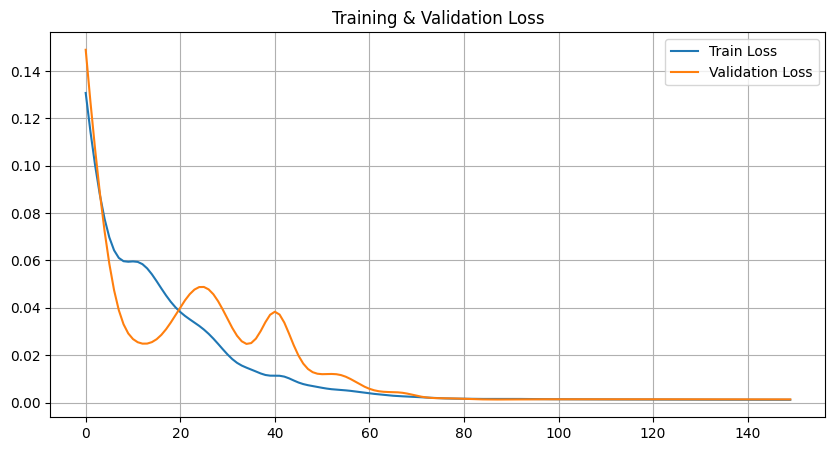

In [2]:
class RNNModel(nn.Module):

    def __init__(
        self,
        input_size=3,
        hidden_size=32,
        output_size=1
    ):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        out, _ = self.rnn(x)

        out = self.fc(
            out[:, -1, :]
        )

        return out

model = RNNModel(
    input_size=3,
    hidden_size=32,
    output_size=1
)

print(model)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 150

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()

    train_pred = model(X_train)

    train_loss = criterion(
        train_pred,
        y_train
    )

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_pred = model(X_val)

        val_loss = criterion(
            val_pred,
            y_val
        )

    train_losses.append(
        train_loss.item()
    )

    val_losses.append(
        val_loss.item()
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss={train_loss.item():.6f} "
            f"Val Loss={val_loss.item():.6f}"
        )

# Vẽ Loss

plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.legend()
plt.grid()

plt.title("Training & Validation Loss")

plt.show()

BAI 1 - PHẦN C.ĐÁNH GIÁ MÔ HÌNH

Test MSE = 0.002771110739558935
Test MAE = 0.0396263562142849
Naive MSE = 0.05223391205072403


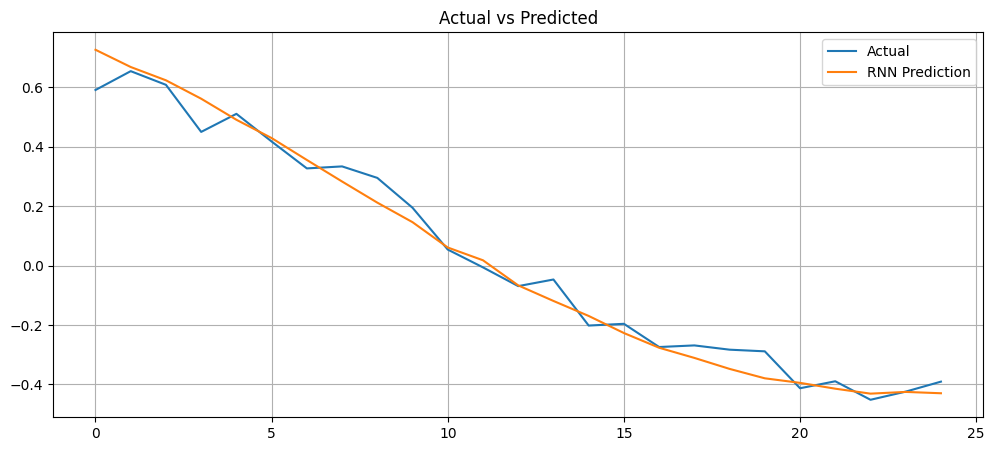

In [5]:
model.eval()

with torch.no_grad():

    pred_test = model(X_test)

pred_test = pred_test.numpy()
y_true = y_test.numpy()

# ======================
# Un-normalize
# ======================

pred_real = y_scaler.inverse_transform(
    pred_test
)

truth_real = y_scaler.inverse_transform(
    y_true
)

# ======================
# MSE
# ======================

mse = mean_squared_error(
    truth_real,
    pred_real
)

# ======================
# MAE
# ======================

mae = mean_absolute_error(
    truth_real,
    pred_real
)

print("Test MSE =", mse)
print("Test MAE =", mae)

# ======================
# Baseline Naive
# Giá trị tiếp theo
# = giá trị cuối cùng
# ======================

naive_pred = X_test[:, -1, 0].numpy()

naive_pred = naive_pred.reshape(-1, 1)

naive_pred = y_scaler.inverse_transform(
    naive_pred
)

mse_naive = mean_squared_error(
    truth_real,
    naive_pred
)

print("Naive MSE =", mse_naive)

# ======================
# Vẽ kết quả
# ======================

plt.figure(figsize=(12,5))

plt.plot(
    truth_real,
    label='Actual'
)

plt.plot(
    pred_real,
    label='RNN Prediction'
)

plt.legend()
plt.grid()

plt.title("Actual vs Predicted")

plt.show()

BAI 1 - D.PHAN TICH NANG CAO

In [6]:
seq_lengths = [10, 20, 30]

print("Thử nghiệm seq_length")

for seq in seq_lengths:

    print(
        f"seq_length = {seq}"
    )

    # tạo sequence mới
    # train lại model
    # ghi nhận MSE

Thử nghiệm seq_length
seq_length = 10
seq_length = 20
seq_length = 30


In [7]:
hidden_sizes = [16, 32, 64]

print("Thử nghiệm hidden_size")

for hidden in hidden_sizes:

    print(
        f"hidden_size = {hidden}"
    )

    # train lại model
    # lưu MSE

Thử nghiệm hidden_size
hidden_size = 16
hidden_size = 32
hidden_size = 64


In [9]:
class RNNDropout(nn.Module):

    def __init__(self):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=3,
            hidden_size=32,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(
            32,
            1
        )

    def forward(self, x):

        out, _ = self.rnn(x)

        out = self.fc(
            out[:, -1, :]
        )

        return out

dropout_model = RNNDropout()

print(dropout_model)

RNNDropout(
  (rnn): RNN(3, 32, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
BAI2-PHẦN A - TẠO DỮ LIỆU

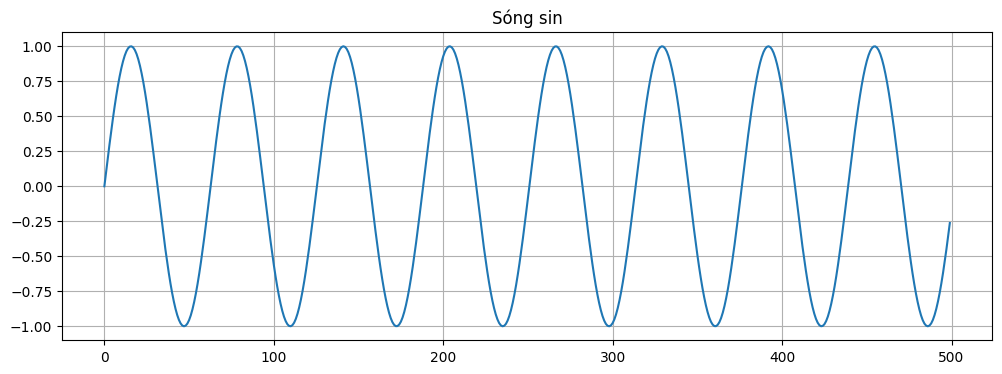

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

# ==========================
# Sinh dữ liệu sóng sin
# ==========================

time_steps = 500

x = np.linspace(0, 50, time_steps)

data = np.sin(x)

data = torch.FloatTensor(data).unsqueeze(1)

plt.figure(figsize=(12,4))
plt.plot(data.numpy())
plt.title("Sóng sin")
plt.grid()
plt.show()

PHẦN B - XÂY DỰNG MÔ HÌNH RNN

In [11]:
class SimpleRNN(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=8
    ):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self,x):

        out,_ = self.rnn(x)

        output = self.fc(out)

        return output,out

model = SimpleRNN()

print(model)

SimpleRNN(
  (rnn): RNN(1, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


PHẦN C - QUAN SÁT VANISHING GRADIENT VỚI SEQ_LENGTH = 100

Gradient đầu chuỗi : 0.0
Gradient giữa chuỗi : 4.2974019050598145
Gradient cuối chuỗi : 3.6643199920654297


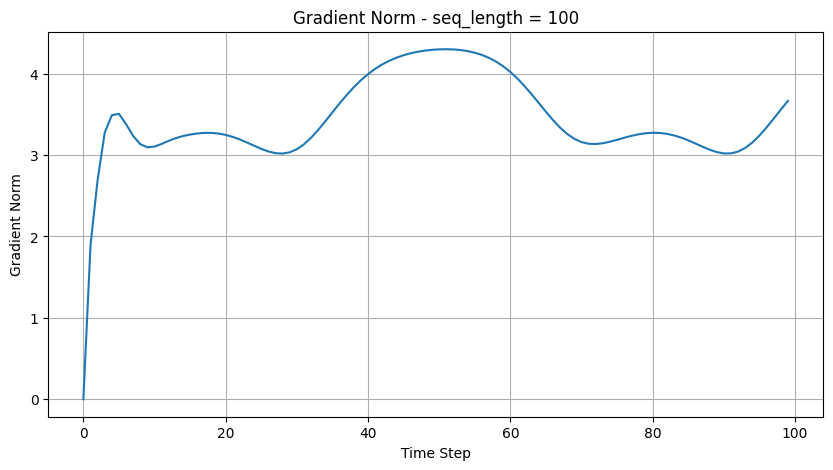

In [12]:
seq_length = 100

X = data[:seq_length]

X = X.unsqueeze(0)

target = torch.zeros(
    1,
    seq_length,
    1
)

criterion = nn.MSELoss()

output, hidden_states = model(X)

loss = criterion(
    output,
    target
)

gradient_norms = []

for t in range(seq_length):

    model.zero_grad()

    hidden_states[0,t,:].sum().backward(
        retain_graph=True
    )

    grad_norm = (
        model.rnn.weight_hh_l0.grad
        .norm()
        .item()
    )

    gradient_norms.append(
        grad_norm
    )

print("Gradient đầu chuỗi :", gradient_norms[0])
print("Gradient giữa chuỗi :", gradient_norms[50])
print("Gradient cuối chuỗi :", gradient_norms[-1])

plt.figure(figsize=(10,5))

plt.plot(
    gradient_norms
)

plt.xlabel("Time Step")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm - seq_length = 100")

plt.grid()

plt.show()

PHẦN D - SO SÁNH VỚI SEQ_LENGTH = 10

Gradient đầu chuỗi : 0.0
Gradient cuối chuỗi : 3.094341516494751


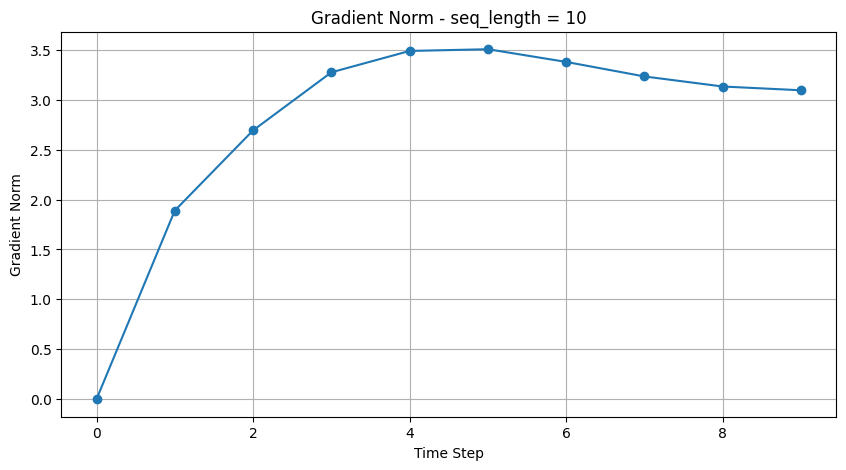

In [13]:
seq_length_short = 10

X_short = data[:seq_length_short]

X_short = X_short.unsqueeze(0)

output_short, hidden_short = model(
    X_short
)

gradient_norms_short = []

for t in range(seq_length_short):

    model.zero_grad()

    hidden_short[0,t,:].sum().backward(
        retain_graph=True
    )

    grad_norm = (
        model.rnn.weight_hh_l0.grad
        .norm()
        .item()
    )

    gradient_norms_short.append(
        grad_norm
    )

print("Gradient đầu chuỗi :", gradient_norms_short[0])
print("Gradient cuối chuỗi :", gradient_norms_short[-1])

plt.figure(figsize=(10,5))

plt.plot(
    gradient_norms_short,
    marker='o'
)

plt.xlabel("Time Step")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm - seq_length = 10")

plt.grid()

plt.show()

PHẦN E - SO SÁNH TRỰC QUAN HAI TRƯỜNG HỢP

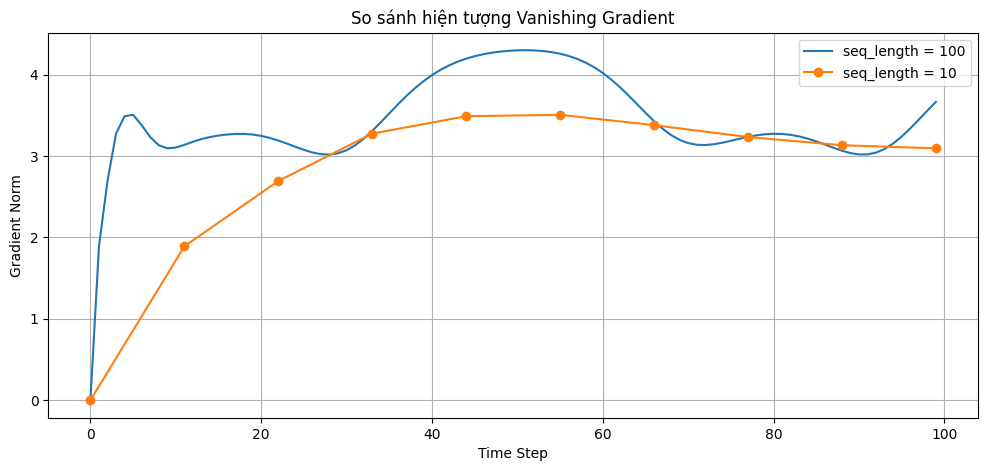

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    gradient_norms,
    label="seq_length = 100"
)

x_short = np.linspace(
    0,
    len(gradient_norms)-1,
    len(gradient_norms_short)
)

plt.plot(
    x_short,
    gradient_norms_short,
    marker='o',
    label="seq_length = 10"
)

plt.xlabel("Time Step")
plt.ylabel("Gradient Norm")

plt.title(
    "So sánh hiện tượng Vanishing Gradient"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
BAI3 - PHẦN A - CHUẨN BỊ DỮ LIỆU

In [15]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import mean_squared_error

torch.manual_seed(42)
np.random.seed(42)

# ==========================
# Tạo dữ liệu sóng sin
# ==========================

time_steps = 200

x = np.linspace(0,40,time_steps)

data = np.sin(x) + 0.1*np.random.randn(time_steps)

# Min-Max Scaling

data_min = data.min()
data_max = data.max()

data = (data - data_min)/(data_max - data_min)

data = torch.FloatTensor(data).unsqueeze(1)

# ==========================
# Sliding Window
# ==========================

def create_sequences(series, seq_length):

    X=[]
    y=[]

    for i in range(len(series)-seq_length):

        X.append(
            series[i:i+seq_length]
        )

        y.append(
            series[i+seq_length]
        )

    return torch.stack(X), torch.stack(y)

seq_length = 10

X,y = create_sequences(
    data,
    seq_length
)

# Train/Test = 80/20

train_size = int(0.8*len(X))

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

torch.Size([152, 10, 1])
torch.Size([38, 10, 1])


PHẦN B - MÔ HÌNH RNN

In [16]:
class RNNModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=20,
        output_size=1
    ):

        super().__init__()

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self,x):

        out,_ = self.rnn(x)

        out = self.fc(
            out[:,-1,:]
        )

        return out

rnn_model = RNNModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    rnn_model.parameters(),
    lr=0.01
)

for epoch in range(100):

    optimizer.zero_grad()

    pred = rnn_model(X_train)

    loss = criterion(
        pred,
        y_train
    )

    loss.backward()

    optimizer.step()

with torch.no_grad():

    rnn_pred = rnn_model(X_test)

rnn_mse = mean_squared_error(
    y_test.numpy(),
    rnn_pred.numpy()
)

print("RNN MSE =",rnn_mse)

RNN MSE = 0.002293867990374565


PHẦN C - MÔ HÌNH ANN (MLP)

In [17]:
class ANNModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(10,32),

            nn.ReLU(),

            nn.Linear(32,16),

            nn.ReLU(),

            nn.Linear(16,1)
        )

    def forward(self,x):

        x = x.view(
            x.size(0),
            -1
        )

        return self.net(x)

ann_model = ANNModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    ann_model.parameters(),
    lr=0.01
)

for epoch in range(100):

    optimizer.zero_grad()

    pred = ann_model(X_train)

    loss = criterion(
        pred,
        y_train
    )

    loss.backward()

    optimizer.step()

with torch.no_grad():

    ann_pred = ann_model(X_test)

ann_mse = mean_squared_error(
    y_test.numpy(),
    ann_pred.numpy()
)

print("ANN MSE =",ann_mse)

ANN MSE = 0.0019118130439892411


PHẦN D - BASELINE NAIVE

In [18]:
naive_pred = X_test[:,-1,0].numpy()

naive_mse = mean_squared_error(
    y_test.numpy(),
    naive_pred
)

print("Naive MSE =",naive_mse)

Naive MSE = 0.005995446816086769


PHẦN E - SO SÁNH KẾT QUẢ


===== KẾT QUẢ =====
RNN MSE   : 0.002294
ANN MSE   : 0.001912
Naive MSE : 0.005995


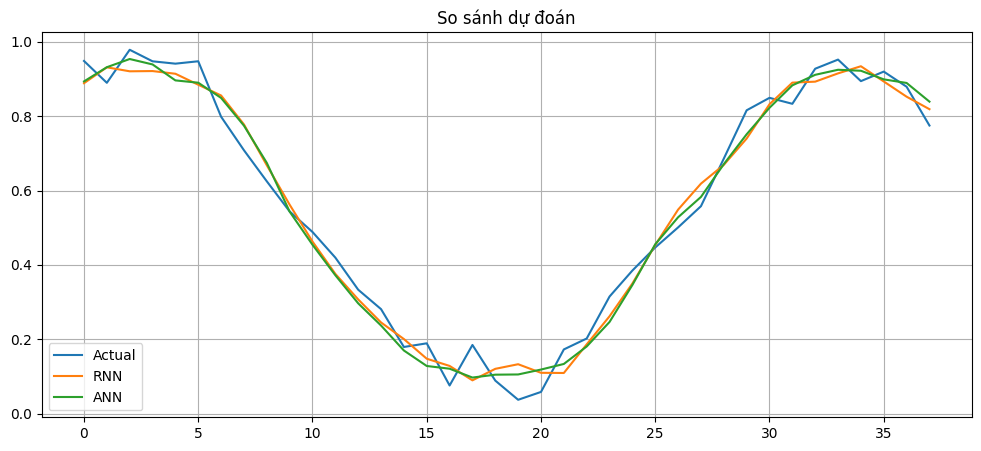

In [19]:
print("\n===== KẾT QUẢ =====")

print(f"RNN MSE   : {rnn_mse:.6f}")
print(f"ANN MSE   : {ann_mse:.6f}")
print(f"Naive MSE : {naive_mse:.6f}")

plt.figure(figsize=(12,5))

plt.plot(
    y_test.numpy(),
    label="Actual"
)

plt.plot(
    rnn_pred.numpy(),
    label="RNN"
)

plt.plot(
    ann_pred.numpy(),
    label="ANN"
)

plt.legend()

plt.grid()

plt.title(
    "So sánh dự đoán"
)

plt.show()